# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [25]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

import torch
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Data


Load the data from Session 11

In [26]:
df = pd.read_csv(os.path.join("..", "..", "lectures", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 1127 entries, 0 to 1127
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SMILES            1127 non-null   str    
 1   LogS              1127 non-null   float64
 2   MolWt             1127 non-null   float64
 3   LogP              1127 non-null   float64
 4   EState_VSA5       1127 non-null   float64
 5   TPSA              1127 non-null   float64
 6   NumHAcc           1127 non-null   float64
 7   NumAromaticRings  1127 non-null   float64
 8   HeavyAtomCount    1127 non-null   float64
 9   RingCount         1127 non-null   float64
 10  qed               1127 non-null   float64
 11  NumHDonors        1127 non-null   float64
 12  NOCount           1127 non-null   float64
dtypes: float64(12), str(1)
memory usage: 123.3 KB


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [28]:
# Using RDKit descriptors as features for the Random Forest model
feature_cols = [c for c in df.columns if c not in ['SMILES', 'LogP']]
X = df[feature_cols]
y = df['LogP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

R²: 0.9135
RMSE: 0.5594


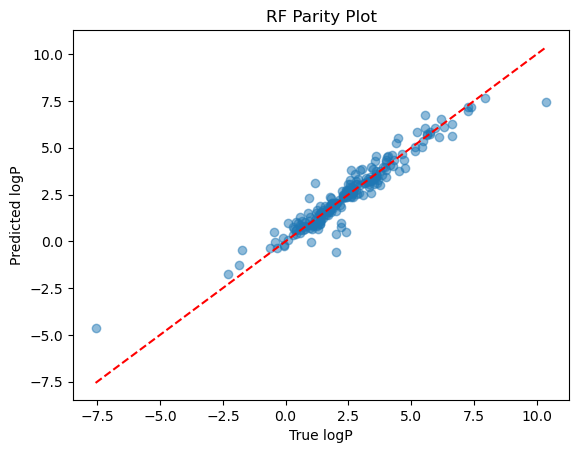

In [29]:
# Random Forest Regressor using RDKit descriptors:
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True logP")
plt.ylabel("Predicted logP")
plt.title("RF Parity Plot")
plt.show()

R² (MACCS): 0.8008
RMSE (MACCS): 0.8489


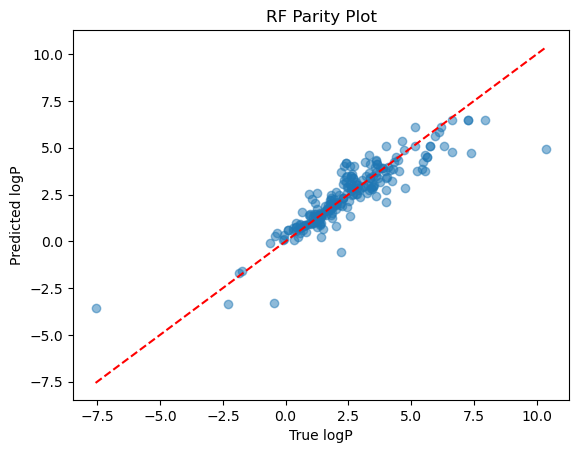

In [30]:
# Random Forest Regressor using MACCS Keys fingerprints:
from rdkit.Chem import MACCSkeys
def maccs_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = MACCSkeys.GenMACCSKeys(mol)
        return np.array(fp)
    else:
        return np.zeros(167)  # MACCS keys have 167 bits

X_fp = np.array([maccs_fingerprint(s) for s in df['SMILES']])
X_train_fp, X_test_fp, y_train_fp, y_test_fp = train_test_split(X_fp, y, test_size=0.2, random_state=42)
RF_fp = RandomForestRegressor(n_estimators=100, random_state=42)
RF_fp.fit(X_train_fp, y_train_fp)
y_pred_fp = RF_fp.predict(X_test_fp)
print(f"R² (MACCS): {r2_score(y_test_fp, y_pred_fp):.4f}")
print(f"RMSE (MACCS): {root_mean_squared_error(y_test_fp, y_pred_fp):.4f}")

plt.scatter(y_test_fp, y_pred_fp, alpha=0.5)
plt.plot([y_test_fp.min(), y_test_fp.max()], [y_test_fp.min(), y_test_fp.max()], 'r--')
plt.xlabel("True logP")
plt.ylabel("Predicted logP")
plt.title("RF Parity Plot")
plt.show()

### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [31]:
# copy functions from session14 notbook

def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions, GNN does not know about directionality of edges in molecules
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

def train(model, train_loader, val_loader, epochs=200, lr=2e-3, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad()
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader)

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | "
              f"Val Loss = {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")

def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(f"R²:   {r2_score(trues, preds):.4f}")
    print(f"RMSE: {root_mean_squared_error(trues, preds):.4f}")


In [32]:
# copy model classes from session14 notebook

# Graph Convolutional Network (GCN)
class GCNModel(torch.nn.Module):
    def __init__(self, dim_h=64): # dim_h: Size of hidden layer
        super().__init__()
        self.conv1 = GCNConv(5, dim_h) # first convolution layer: in_channels: 5, number of atom features
        self.conv2 = GCNConv(dim_h, dim_h) # second convolution layer
        self.lin = torch.nn.Linear(dim_h, 1) # output layer
        
    # Define how the data flows through the layers
    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))  # input layer: convolution + activation function (ReLu)
        x = torch.relu(self.conv2(x, edge_index))  # hidden layer: convolution + activation function (ReLu)
        x = global_mean_pool(x, batch)             # pooling function
        return self.lin(x).squeeze(-1)

# Graph Isomorphism Network (GIN)
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # try: global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)

# Graph Attention Network (GAT)
class GATModel(torch.nn.Module):
    def __init__(self, dim_h=64, heads=4):
        super().__init__()

        # Input layer
        self.conv1 = GATConv(
            in_channels=5,        # your atom feature size
            out_channels=dim_h,  # hidden dimension per head
            heads=heads,
            dropout=0.1,
            concat=True           # concatenates heads --> output = hidden * heads
        )

        # Second layer
        self.conv2 = GATConv(
            in_channels=dim_h * heads,
            out_channels=dim_h,
            heads=1,
            dropout=0.1,
            concat=False          # final output shape = (hidden,)
        )

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [33]:
# Convert all SMILES to graph data objects
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [34]:
# Create train/val/test splits
train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [35]:
# training GCN for 10 epochs
gcn = GCNModel()
gin = GINModel()
gat = GATModel()

epochs = 1000

print("\n=== Training GCN ===")
train(gcn, train_loader, val_loader, epochs=epochs)
test(gcn, test_loader)

print("\n=== Training GIN ===")
train(gin, train_loader, val_loader, epochs=epochs)
test(gin, test_loader)

print("\n=== Training GAT ===")
train(gat, train_loader, val_loader, epochs=epochs)
test(gat, test_loader)


=== Training GCN ===
Epoch 01 | Train Loss = 4.5069 | Val Loss = 5.3626
Epoch 02 | Train Loss = 3.5066 | Val Loss = 4.9889
Epoch 03 | Train Loss = 3.2947 | Val Loss = 4.9607
Epoch 04 | Train Loss = 3.1915 | Val Loss = 4.8869
Epoch 05 | Train Loss = 3.1942 | Val Loss = 4.8185
Epoch 06 | Train Loss = 3.3004 | Val Loss = 4.9192
Epoch 07 | Train Loss = 3.0763 | Val Loss = 4.7520
Epoch 08 | Train Loss = 3.0392 | Val Loss = 4.5946
Epoch 09 | Train Loss = 2.9564 | Val Loss = 4.7206
Epoch 10 | Train Loss = 3.0969 | Val Loss = 4.6236
Epoch 11 | Train Loss = 3.1132 | Val Loss = 4.4522
Epoch 12 | Train Loss = 2.9363 | Val Loss = 4.3386
Epoch 13 | Train Loss = 3.1272 | Val Loss = 4.4994
Epoch 14 | Train Loss = 2.8409 | Val Loss = 4.2114
Epoch 15 | Train Loss = 2.7213 | Val Loss = 4.1352
Epoch 16 | Train Loss = 2.7770 | Val Loss = 3.9575
Epoch 17 | Train Loss = 2.6875 | Val Loss = 3.7505
Epoch 18 | Train Loss = 2.6008 | Val Loss = 3.5754
Epoch 19 | Train Loss = 2.5034 | Val Loss = 3.5489
Epoch 20 

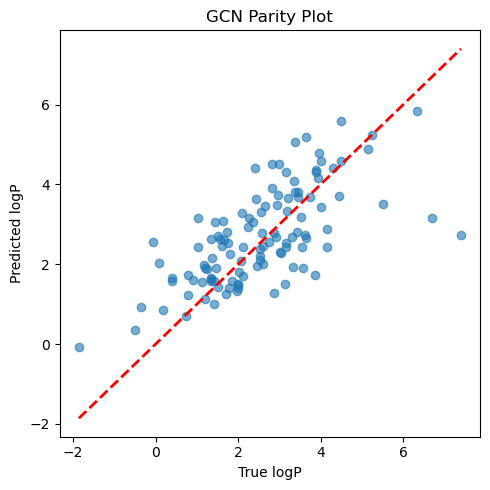

R²:   0.4308
RMSE: 1.1006


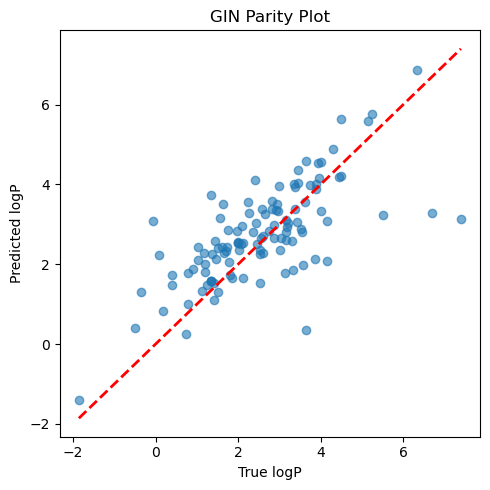

R²:   0.4542
RMSE: 1.0778


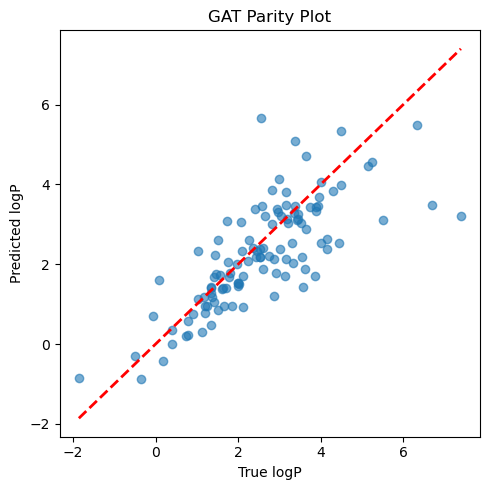

R²:   0.5324
RMSE: 0.9976


In [36]:
# plot parity plot for all three models
parity_plot(gcn, test_loader, title="GCN Parity Plot")
parity_plot(gin, test_loader, title="GIN Parity Plot")
parity_plot(gat, test_loader, title="GAT Parity Plot")

### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
2) What did you try to improve model performance of your GNN? What did work, what did not work?
3) Which challenges did you face in the process of building the models?
4) Which of your two models would you recommend to a chemist for predicting logP, and why?

1. the rf (rdkit descriptors and maccs) outperforms the gnns. the dataset is medium in size and the rdkit descriptors already encode physicochemical properties that directly relate to logP (logS, TPSA, ring count). gnns have to learn these relationships from scratch. with more data the gap would probably close.
2. included dataloader and added early stopping to avoid overtraining. tried all three architectures (gcn, gin, gat) but copied models directly from session 14 without changes. only learning rate was tested wit 0.002, 0.001, and 0.0001 as options, where 0.002 performed a little better than 0.001, both significantly better and faster than 0.0001.
3. the uv environment as usual ;) besides that runtime on training 3 nn's took a few minutes. RF performed well out of the box.
4. with this dataset rdkit with RF is easy to implement, works fast and yields the best results. if a nn is desired, out of these 3 GAT performed best.